In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import random
import numpy as np
import spacy
import datasets
import torchtext
import tqdm
import evaluate
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# New libraries for stress testing and training on bigger dataset
import pandas as pd
from pyarrow import Table
from pyarrow import array as pa_array
from random import sample

In [2]:
seed = 1234

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True

In [3]:
dataset = datasets.load_dataset("bentrevett/multi30k")
dataset

DatasetDict({
    train: Dataset({
        features: ['en', 'de'],
        num_rows: 29000
    })
    validation: Dataset({
        features: ['en', 'de'],
        num_rows: 1014
    })
    test: Dataset({
        features: ['en', 'de'],
        num_rows: 1000
    })
})

In [4]:
train_data, valid_data, test_data = (
    dataset["train"],
    dataset["validation"],
    dataset["test"],
)

In [5]:
en_nlp = spacy.load("en_core_web_sm")
de_nlp = spacy.load("de_core_news_sm")

In [6]:
def tokenize_example(example, en_nlp, de_nlp, max_length, lower, sos_token, eos_token):
    en_tokens = [token.text for token in en_nlp.tokenizer(example["en"])][:max_length]
    de_tokens = [token.text for token in de_nlp.tokenizer(example["de"])][:max_length]
    if lower:
        en_tokens = [token.lower() for token in en_tokens]
        de_tokens = [token.lower() for token in de_tokens]
    en_tokens = [sos_token] + en_tokens + [eos_token]
    de_tokens = [sos_token] + de_tokens + [eos_token]
    return {"en_tokens": en_tokens, "de_tokens": de_tokens}

In [7]:
max_length = 1_000
lower = True
sos_token = "<sos>"
eos_token = "<eos>"

fn_kwargs = {
    "en_nlp": en_nlp,
    "de_nlp": de_nlp,
    "max_length": max_length,
    "lower": lower,
    "sos_token": sos_token,
    "eos_token": eos_token,
}

train_data = train_data.map(tokenize_example, fn_kwargs=fn_kwargs)
valid_data = valid_data.map(tokenize_example, fn_kwargs=fn_kwargs)
test_data = test_data.map(tokenize_example, fn_kwargs=fn_kwargs)

In [8]:
# With tortext >0.9, torchtext.vocab.build_vocab_from_iterator must be imported instead of called directly
from torchtext.vocab import build_vocab_from_iterator

/home/pikasan/.pyenv/versions/miniconda3-latest/lib/python3.12/site-packages/torchtext/vocab/__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)
/home/pikasan/.pyenv/versions/miniconda3-latest/lib/python3.12/site-packages/torchtext/utils.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)


In [9]:
min_freq = 2
unk_token = "<unk>"
pad_token = "<pad>"

special_tokens = [
    unk_token,
    pad_token,
    sos_token,
    eos_token,
]

en_vocab = build_vocab_from_iterator(
    train_data["en_tokens"],
    min_freq=min_freq,
    specials=special_tokens,
)

de_vocab = build_vocab_from_iterator(
    train_data["de_tokens"],
    min_freq=min_freq,
    specials=special_tokens,
)

In [10]:
assert en_vocab[unk_token] == de_vocab[unk_token]
assert en_vocab[pad_token] == de_vocab[pad_token]

unk_index = en_vocab[unk_token]
pad_index = en_vocab[pad_token]

In [11]:
en_vocab.set_default_index(unk_index)
de_vocab.set_default_index(unk_index)

In [12]:
def numericalize_example(example, en_vocab, de_vocab):
    en_ids = en_vocab.lookup_indices(example["en_tokens"])
    de_ids = de_vocab.lookup_indices(example["de_tokens"])
    return {"en_ids": en_ids, "de_ids": de_ids}

In [13]:
fn_kwargs = {"en_vocab": en_vocab, "de_vocab": de_vocab}

train_data = train_data.map(numericalize_example, fn_kwargs=fn_kwargs)
valid_data = valid_data.map(numericalize_example, fn_kwargs=fn_kwargs)
test_data = test_data.map(numericalize_example, fn_kwargs=fn_kwargs)

In [14]:
data_type = "torch"
format_columns = ["en_ids", "de_ids"]

train_data = train_data.with_format(
    type=data_type, columns=format_columns, output_all_columns=True
)

valid_data = valid_data.with_format(
    type=data_type,
    columns=format_columns,
    output_all_columns=True,
)

test_data = test_data.with_format(
    type=data_type,
    columns=format_columns,
    output_all_columns=True,
)

In [15]:
def get_collate_fn(pad_index):
    def collate_fn(batch):
        batch_en_ids = [example["en_ids"] for example in batch]
        batch_de_ids = [example["de_ids"] for example in batch]
        batch_en_ids = nn.utils.rnn.pad_sequence(batch_en_ids, padding_value=pad_index)
        batch_de_ids = nn.utils.rnn.pad_sequence(batch_de_ids, padding_value=pad_index)
        batch = {
            "en_ids": batch_en_ids,
            "de_ids": batch_de_ids,
        }
        return batch

    return collate_fn

In [16]:
def get_data_loader(dataset, batch_size, pad_index, shuffle=False):
    collate_fn = get_collate_fn(pad_index)
    data_loader = torch.utils.data.DataLoader(
        dataset=dataset,
        batch_size=batch_size,
        collate_fn=collate_fn,
        shuffle=shuffle,
    )
    return data_loader

In [17]:
batch_size = 128

train_data_loader = get_data_loader(train_data, batch_size, pad_index, shuffle=True)
valid_data_loader = get_data_loader(valid_data, batch_size, pad_index)
test_data_loader = get_data_loader(test_data, batch_size, pad_index)

In [18]:
class Encoder(nn.Module):
    def __init__(
        self, input_dim, embedding_dim, encoder_hidden_dim, decoder_hidden_dim, dropout
    ):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, embedding_dim)
        self.rnn = nn.GRU(embedding_dim, encoder_hidden_dim, bidirectional=True)
        self.fc = nn.Linear(encoder_hidden_dim * 2, decoder_hidden_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        # src = [src length, batch size]
        embedded = self.dropout(self.embedding(src))
        # embedded = [src length, batch size, embedding dim]
        outputs, hidden = self.rnn(embedded)
        # outputs = [src length, batch size, hidden dim * n directions]
        # hidden = [n layers * n directions, batch size, hidden dim]
        # hidden is stacked [forward_1, backward_1, forward_2, backward_2, ...]
        # outputs are always from the last layer
        # hidden [-2, :, : ] is the last of the forwards RNN
        # hidden [-1, :, : ] is the last of the backwards RNN
        # initial decoder hidden is final hidden state of the forwards and backwards
        # encoder RNNs fed through a linear layer
        hidden = torch.tanh(
            self.fc(torch.cat((hidden[-2, :, :], hidden[-1, :, :]), dim=1))
        )
        # outputs = [src length, batch size, encoder hidden dim * 2]
        # hidden = [batch size, decoder hidden dim]
        return outputs, hidden

In [19]:
class Attention(nn.Module):
    def __init__(self, encoder_hidden_dim, decoder_hidden_dim):
        super().__init__()
        self.attn_fc = nn.Linear(
            (encoder_hidden_dim * 2) + decoder_hidden_dim, decoder_hidden_dim
        )
        self.v_fc = nn.Linear(decoder_hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        # hidden = [batch size, decoder hidden dim]
        # encoder_outputs = [src length, batch size, encoder hidden dim * 2]
        batch_size = encoder_outputs.shape[1]
        src_length = encoder_outputs.shape[0]
        # repeat decoder hidden state src_length times
        hidden = hidden.unsqueeze(1).repeat(1, src_length, 1)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)
        # hidden = [batch size, src length, decoder hidden dim]
        # encoder_outputs = [batch size, src length, encoder hidden dim * 2]
        energy = torch.tanh(self.attn_fc(torch.cat((hidden, encoder_outputs), dim=2)))
        # energy = [batch size, src length, decoder hidden dim]
        attention = self.v_fc(energy).squeeze(2)
        # attention = [batch size, src length]
        return torch.softmax(attention, dim=1)

In [20]:
class Decoder(nn.Module):
    def __init__(
        self,
        output_dim,
        embedding_dim,
        encoder_hidden_dim,
        decoder_hidden_dim,
        dropout,
        attention,
    ):
        super().__init__()
        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, embedding_dim)
        self.rnn = nn.GRU((encoder_hidden_dim * 2) + embedding_dim, decoder_hidden_dim)
        self.fc_out = nn.Linear(
            (encoder_hidden_dim * 2) + decoder_hidden_dim + embedding_dim, output_dim
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, input, hidden, encoder_outputs):
        # input = [batch size]
        # hidden = [batch size, decoder hidden dim]
        # encoder_outputs = [src length, batch size, encoder hidden dim * 2]
        input = input.unsqueeze(0)
        # input = [1, batch size]
        embedded = self.dropout(self.embedding(input))
        # embedded = [1, batch size, embedding dim]
        a = self.attention(hidden, encoder_outputs)
        # a = [batch size, src length]
        a = a.unsqueeze(1)
        # a = [batch size, 1, src length]
        encoder_outputs = encoder_outputs.permute(1, 0, 2)
        # encoder_outputs = [batch size, src length, encoder hidden dim * 2]
        weighted = torch.bmm(a, encoder_outputs)
        # weighted = [batch size, 1, encoder hidden dim * 2]
        weighted = weighted.permute(1, 0, 2)
        # weighted = [1, batch size, encoder hidden dim * 2]
        rnn_input = torch.cat((embedded, weighted), dim=2)
        # rnn_input = [1, batch size, (encoder hidden dim * 2) + embedding dim]
        output, hidden = self.rnn(rnn_input, hidden.unsqueeze(0))
        # output = [seq length, batch size, decoder hid dim * n directions]
        # hidden = [n layers * n directions, batch size, decoder hid dim]
        # seq len, n layers and n directions will always be 1 in this decoder, therefore:
        # output = [1, batch size, decoder hidden dim]
        # hidden = [1, batch size, decoder hidden dim]
        # this also means that output == hidden
        assert (output == hidden).all()
        embedded = embedded.squeeze(0)
        output = output.squeeze(0)
        weighted = weighted.squeeze(0)
        prediction = self.fc_out(torch.cat((output, weighted, embedded), dim=1))
        # prediction = [batch size, output dim]
        return prediction, hidden.squeeze(0), a.squeeze(1)

In [21]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg, teacher_forcing_ratio):
        # src = [src length, batch size]
        # trg = [trg length, batch size]
        # teacher_forcing_ratio is probability to use teacher forcing
        # e.g. if teacher_forcing_ratio is 0.75 we use teacher forcing 75% of the time
        batch_size = src.shape[1]
        trg_length = trg.shape[0]
        trg_vocab_size = self.decoder.output_dim
        # tensor to store decoder outputs
        outputs = torch.zeros(trg_length, batch_size, trg_vocab_size).to(self.device)
        # encoder_outputs is all hidden states of the input sequence, back and forwards
        # hidden is the final forward and backward hidden states, passed through a linear layer
        encoder_outputs, hidden = self.encoder(src)
        # outputs = [src length, batch size, encoder hidden dim * 2]
        # hidden = [batch size, decoder hidden dim]
        # first input to the decoder is the <sos> tokens
        input = trg[0, :]
        for t in range(1, trg_length):
            # insert input token embedding, previous hidden state and all encoder hidden states
            # receive output tensor (predictions) and new hidden state
            output, hidden, _ = self.decoder(input, hidden, encoder_outputs)
            # output = [batch size, output dim]
            # hidden = [n layers, batch size, decoder hidden dim]
            # place predictions in a tensor holding predictions for each token
            outputs[t] = output
            # decide if we are going to use teacher forcing or not
            teacher_force = random.random() < teacher_forcing_ratio
            # get the highest predicted token from our predictions
            top1 = output.argmax(1)
            # if teacher forcing, use actual next token as next input
            # if not, use predicted token
            input = trg[t] if teacher_force else top1
            # input = [batch size]
        return outputs

In [22]:
input_dim = len(de_vocab)
output_dim = len(en_vocab)
encoder_embedding_dim = 256
decoder_embedding_dim = 256
encoder_hidden_dim = 512
decoder_hidden_dim = 512
encoder_dropout = 0.5
decoder_dropout = 0.5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

attention = Attention(encoder_hidden_dim, decoder_hidden_dim)

encoder = Encoder(
    input_dim,
    encoder_embedding_dim,
    encoder_hidden_dim,
    decoder_hidden_dim,
    encoder_dropout,
)

decoder = Decoder(
    output_dim,
    decoder_embedding_dim,
    encoder_hidden_dim,
    decoder_hidden_dim,
    decoder_dropout,
    attention,
)

model = Seq2Seq(encoder, decoder, device).to(device)

In [23]:
def init_weights(m):
    for name, param in m.named_parameters():
        if "weight" in name:
            nn.init.normal_(param.data, mean=0, std=0.01)
        else:
            nn.init.constant_(param.data, 0)


model.apply(init_weights)

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(7853, 256)
    (rnn): GRU(256, 512, bidirectional=True)
    (fc): Linear(in_features=1024, out_features=512, bias=True)
    (dropout): Dropout(p=0.5, inplace=False)
  )
  (decoder): Decoder(
    (attention): Attention(
      (attn_fc): Linear(in_features=1536, out_features=512, bias=True)
      (v_fc): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(5893, 256)
    (rnn): GRU(1280, 512)
    (fc_out): Linear(in_features=1792, out_features=5893, bias=True)
    (dropout): Dropout(p=0.5, inplace=False)
  )
)

In [24]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


print(f"The model has {count_parameters(model):,} trainable parameters")

The model has 20,518,405 trainable parameters


In [25]:
optimizer = optim.Adam(model.parameters())

In [26]:
criterion = nn.CrossEntropyLoss(ignore_index=pad_index)

In [27]:
def train_fn(
    model, data_loader, optimizer, criterion, clip, teacher_forcing_ratio, device
):
    model.train()
    epoch_loss = 0
    for i, batch in enumerate(data_loader):
        src = batch["de_ids"].to(device)
        trg = batch["en_ids"].to(device)
        # src = [src length, batch size]
        # trg = [trg length, batch size]
        optimizer.zero_grad()
        output = model(src, trg, teacher_forcing_ratio)
        # output = [trg length, batch size, trg vocab size]
        output_dim = output.shape[-1]
        output = output[1:].view(-1, output_dim)
        # output = [(trg length - 1) * batch size, trg vocab size]
        trg = trg[1:].view(-1)
        # trg = [(trg length - 1) * batch size]
        loss = criterion(output, trg)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        epoch_loss += loss.item()
    return epoch_loss / len(data_loader)

In [28]:
def evaluate_fn(model, data_loader, criterion, device):
    model.eval()
    epoch_loss = 0
    with torch.no_grad():
        for i, batch in enumerate(data_loader):
            src = batch["de_ids"].to(device)
            trg = batch["en_ids"].to(device)
            # src = [src length, batch size]
            # trg = [trg length, batch size]
            output = model(src, trg, 0)  # turn off teacher forcing
            # output = [trg length, batch size, trg vocab size]
            output_dim = output.shape[-1]
            output = output[1:].view(-1, output_dim)
            # output = [(trg length - 1) * batch size, trg vocab size]
            trg = trg[1:].view(-1)
            # trg = [(trg length - 1) * batch size]
            loss = criterion(output, trg)
            epoch_loss += loss.item()
    return epoch_loss / len(data_loader)

In [29]:
n_epochs = 10
clip = 1.0
teacher_forcing_ratio = 0.5

best_valid_loss = float("inf")

for epoch in tqdm.tqdm(range(n_epochs)):
    train_loss = train_fn(
        model,
        train_data_loader,
        optimizer,
        criterion,
        clip,
        teacher_forcing_ratio,
        device,
    )
    valid_loss = evaluate_fn(
        model,
        valid_data_loader,
        criterion,
        device,
    )
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), "tut3-model.pt")
    print(f"\tTrain Loss: {train_loss:7.3f} | Train PPL: {np.exp(train_loss):7.3f}")
    print(f"\tValid Loss: {valid_loss:7.3f} | Valid PPL: {np.exp(valid_loss):7.3f}")

 10%|████████▍                                                                           | 1/10 [00:50<07:30, 50.03s/it]

	Train Loss:   5.008 | Train PPL: 149.655
	Valid Loss:   4.781 | Valid PPL: 119.254


 20%|████████████████▊                                                                   | 2/10 [01:40<06:43, 50.40s/it]

	Train Loss:   4.159 | Train PPL:  63.995
	Valid Loss:   4.422 | Valid PPL:  83.230


 30%|█████████████████████████▏                                                          | 3/10 [02:30<05:49, 49.91s/it]

...

	Train Loss:   1.800 | Train PPL:   6.047
	Valid Loss:   3.356 | Valid PPL:  28.674


 90%|███████████████████████████████████████████████████████████████████████████▌        | 9/10 [07:23<00:48, 48.96s/it]

	Train Loss:   1.639 | Train PPL:   5.152
	Valid Loss:   3.334 | Valid PPL:  28.045


100%|███████████████████████████████████████████████████████████████████████████████████| 10/10 [08:13<00:00, 49.31s/it]

	Train Loss:   1.492 | Train PPL:   4.445
	Valid Loss:   3.410 | Valid PPL:  30.276


In [30]:
model.load_state_dict(torch.load("tut3-model.pt"))

test_loss = evaluate_fn(model, test_data_loader, criterion, device)

print(f"| Test Loss: {test_loss:.3f} | Test PPL: {np.exp(test_loss):7.3f} |")

| Test Loss: 3.305 | Test PPL:  27.242 |


In [31]:
def translate_sentence(
    sentence,
    model,
    en_nlp,
    de_nlp,
    en_vocab,
    de_vocab,
    lower,
    sos_token,
    eos_token,
    device,
    max_output_length=25,
):
    model.eval()
    with torch.no_grad():
        if isinstance(sentence, str):
            de_tokens = [token.text for token in de_nlp.tokenizer(sentence)]
        else:
            de_tokens = [token for token in sentence]
        if lower:
            de_tokens = [token.lower() for token in de_tokens]
        de_tokens = [sos_token] + de_tokens + [eos_token]
        ids = de_vocab.lookup_indices(de_tokens)
        tensor = torch.LongTensor(ids).unsqueeze(-1).to(device)
        encoder_outputs, hidden = model.encoder(tensor)
        inputs = en_vocab.lookup_indices([sos_token])
        attentions = torch.zeros(max_output_length, 1, len(ids))
        for i in range(max_output_length):
            inputs_tensor = torch.LongTensor([inputs[-1]]).to(device)
            output, hidden, attention = model.decoder(
                inputs_tensor, hidden, encoder_outputs
            )
            attentions[i] = attention
            predicted_token = output.argmax(-1).item()
            inputs.append(predicted_token)
            if predicted_token == en_vocab[eos_token]:
                break
        en_tokens = en_vocab.lookup_tokens(inputs)
    return en_tokens, de_tokens, attentions[: len(en_tokens) - 1]

In [32]:
def plot_attention(sentence, translation, attention):
    fig, ax = plt.subplots(figsize=(10, 10))
    attention = attention.squeeze(1).numpy()
    cax = ax.matshow(attention, cmap="bone")
    ax.set_xticks(ticks=np.arange(len(sentence)), labels=sentence, rotation=90, size=15)
    translation = translation[1:]
    ax.set_yticks(ticks=np.arange(len(translation)), labels=translation, size=15)
    plt.show()
    plt.close()

In [33]:
sentence = test_data[0]["de"]
expected_translation = test_data[0]["en"]

sentence, expected_translation

('Ein Mann mit einem orangefarbenen Hut, der etwas anstarrt.',
 'A man in an orange hat starring at something.')

In [34]:
translation, sentence_tokens, attention = translate_sentence(
    sentence,
    model,
    en_nlp,
    de_nlp,
    en_vocab,
    de_vocab,
    lower,
    sos_token,
    eos_token,
    device,
)

In [35]:
translation

['<sos>',
 'a',
 'man',
 'in',
 'an',
 'orange',
 'hat',
 'is',
 'welding',
 'something',
 '.',
 '<eos>']

In [36]:
sentence_tokens

['<sos>',
 'ein',
 'mann',
 'mit',
 'einem',
 'orangefarbenen',
 'hut',
 ',',
 'der',
 'etwas',
 'anstarrt',
 '.',
 '<eos>']

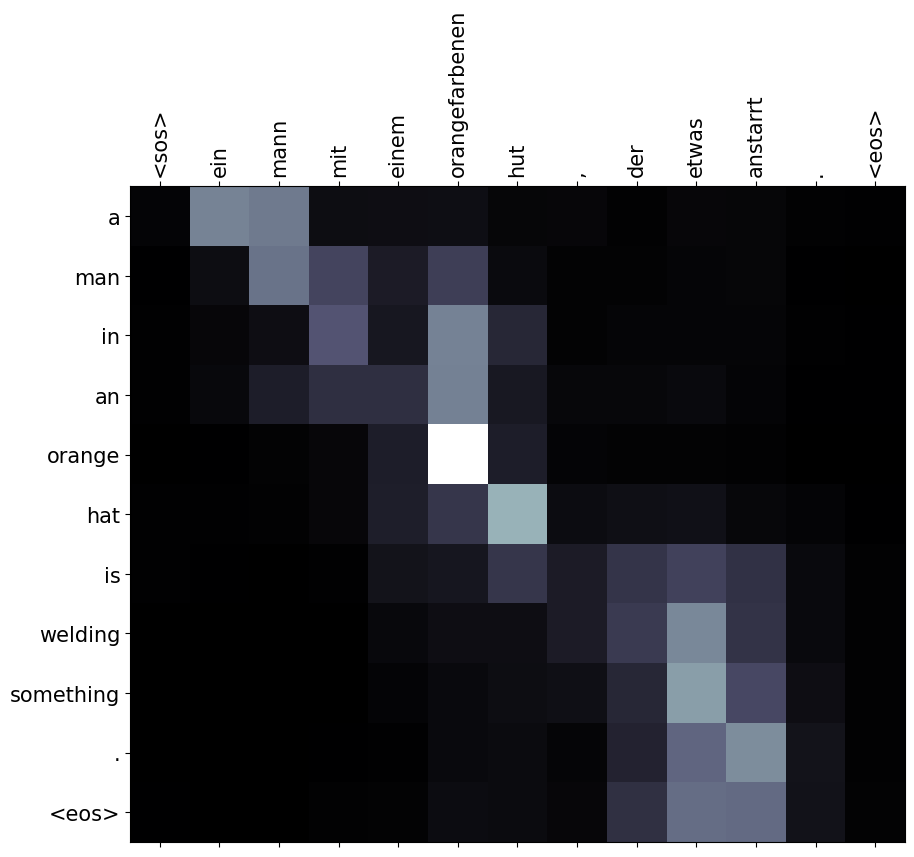

In [37]:
plot_attention(sentence_tokens, translation, attention)

In [38]:
sentence = "Ein Mann sieht sich einen Film an."

In [39]:
translation, sentence_tokens, attention = translate_sentence(
    sentence,
    model,
    en_nlp,
    de_nlp,
    en_vocab,
    de_vocab,
    lower,
    sos_token,
    eos_token,
    device,
)

In [40]:
translation

['<sos>', 'a', 'man', 'is', 'looking', 'at', 'a', 'conference', '.', '<eos>']

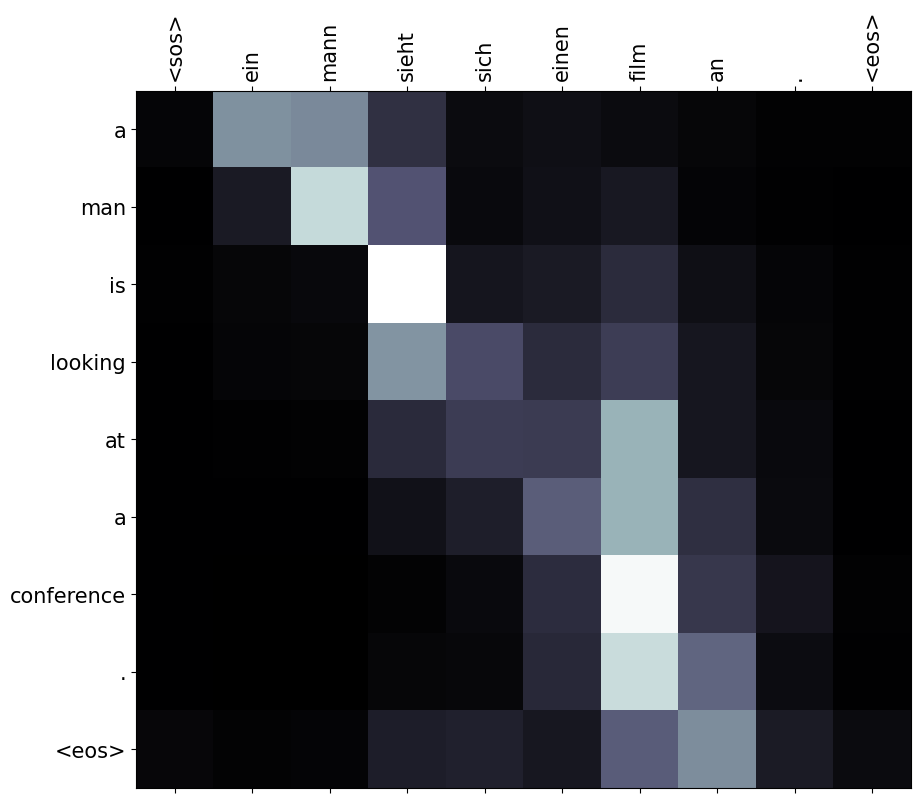

In [41]:
plot_attention(sentence_tokens, translation, attention)

In [42]:
translations = [
    translate_sentence(
        example["de"],
        model,
        en_nlp,
        de_nlp,
        en_vocab,
        de_vocab,
        lower,
        sos_token,
        eos_token,
        device,
    )[0]
    for example in tqdm.tqdm(test_data)
]

100%|███████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:19<00:00, 50.08it/s]


In [43]:
bleu = evaluate.load("bleu")

In [44]:
predictions = [" ".join(translation[1:-1]) for translation in translations]

references = [[example["en"]] for example in test_data]

In [45]:
def get_tokenizer_fn(nlp, lower):
    def tokenizer_fn(s):
        tokens = [token.text for token in nlp.tokenizer(s)]
        if lower:
            tokens = [token.lower() for token in tokens]
        return tokens

    return tokenizer_fn

In [46]:
tokenizer_fn = get_tokenizer_fn(en_nlp, lower)

In [47]:
results = bleu.compute(
    predictions=predictions, references=references, tokenizer=tokenizer_fn
)

In [48]:
results

{'bleu': 0.2583046682746609,
 'precisions': [0.5782342342342343,
  0.333126213592233,
  0.19528421052631578,
  0.1183448275862069],
 'brevity_penalty': 1.0,
 'length_ratio': 1.0625670087302803,
 'translation_length': 13875,
 'reference_length': 13058}

# Flaw Search
## Test Large Dataset
**NOTE: The following was copied from my earlier attempt to train on the larger data. This applies for translation testing aas well. Training was abandoned due to hardware limitations and it can be assumed that it may take at least 5 hours to train 1 epoch. Translation testing can take between 15-40 hours.**

<s>
The new dataset has 4592289 training entries. Training on this many entries requires a GPU that allows PyTorch to allocate GBs worth of data in cuda. A `OutOfMemoryError: CUDA out of memory. Tried to allocate <> GiB. GPU` error might/will occur if it cannot allocate the space while training at different epochs. Note that the memory allocation error will be less than your GPUs actual memory. This is the **additional** memory it's trying to allocate, meaning it's likely PyTorch was already utilizing all `x` GB of GPU memory before it ran out of space.

Alternatively, the (adapted) code can be modified to use on multiple GPUs. Please specify below for `training_percentage` to limit the percentage of the full training data to use. If memory is still an issue, adjust teh `batch_size`. Use `torch.cuda.memory_summary(device=None, abbreviated=False)` to see GPU allocation.

For this modified training, a `training_percentage=0.007` will be used alongside a `batch_size=128` such that it's slightly more data than the original implementation. The other reasoning is due to hardware limitations.
</s>

**NOTE: Cropping occurs in the converted dataset, process of converting still iterates through all <s>4592289</s> rows**

In [49]:
# Load new larger de-en dataset
tmp_dataset = datasets.load_dataset("wmt/wmt_t2t") # https://huggingface.co/datasets/wmt/wmt_t2t

# #### MODIFY THIS ACCORDINGLY
large_dataset_percentage = 0.001   # Set to 1.0 for full training set
# ############################

# Convert dataset to match original schema
large_dataset = None
ens = []
des = []
for subset_name, subset in tmp_dataset.items():
    # Generate random index selection to use in cropped data
    crop_sz = max(int(large_dataset_percentage * subset.shape[0]), 1)
    cropped_random_ids = sample(range(0, subset.shape[0]), crop_sz) if int(large_dataset_percentage) != 1 else []   # If 1.0 -> no crop, don't waste time generating
    cropped_random_ids.sort()   # For random selection performance boost later

    idx_selection_idx = 0 
    selected_indx = cropped_random_ids[idx_selection_idx] if len(cropped_random_ids) != 0 else None
    for i, row in enumerate(tqdm.tqdm(subset, desc=f'Randomly appending {crop_sz} "{subset_name}" data')):   
        # Append en and de sentences. Accessing 'translation' here to skip unpacking step that occurs when iterating through subset['translation']
        if i == selected_indx or selected_indx == None:
            ens.append(row['translation']['en'])
            des.append(row['translation']['de'])
            
            # Update with next crop selected idx if not None (which is no crop)
            if selected_indx != None:
                idx_selection_idx += 1
                selected_indx = cropped_random_ids[idx_selection_idx if idx_selection_idx < crop_sz else 0]

Randomly appending 3 "test" data: 100%|██████████████████████████████████████████| 3003/3003 [00:00<00:00, 60856.92it/s]


In [50]:
large_dataset = datasets.Dataset(Table.from_arrays([pa_array(ens), pa_array(des)], names=['en', 'de']))
large_dataset

Dataset({
    features: ['en', 'de'],
    num_rows: 4598
})

In [51]:
# Tokenize Stress Data
fn_kwargs = {
    "en_nlp": en_nlp,
    "de_nlp": de_nlp,
    "max_length": max_length,
    "lower": lower,
    "sos_token": sos_token,
    "eos_token": eos_token,
}
large_data = large_dataset.map(tokenize_example, fn_kwargs=fn_kwargs)

# Get Token IDS for Stress Data
fn_kwargs = {"en_vocab": en_vocab, "de_vocab": de_vocab}
large_data = large_data.map(numericalize_example, fn_kwargs=fn_kwargs)

Map:   0%|          | 0/4598 [00:00<?, ? examples/s]

Map:   0%|          | 0/4598 [00:00<?, ? examples/s]

In [52]:
large_data = large_data.with_format(
    type=data_type,
    columns=format_columns,
    output_all_columns=True,
)

In [53]:
model.load_state_dict(torch.load("tut3-model.pt"))

large_translations = [
    translate_sentence(
        example["de"],
        model,
        en_nlp,
        de_nlp,
        en_vocab,
        de_vocab,
        lower,
        sos_token,
        eos_token,
        device,
    )
    for example in tqdm.tqdm(large_data)
]

100%|███████████████████████████████████████████████████████████████████████████████| 4598/4598 [01:55<00:00, 39.84it/s]


In [70]:
bleu = evaluate.load("bleu")
predictions = [" ".join(translation[0][1:-1]) for translation in large_translations]
references = [[example["en"]] for example in large_data]

In [55]:
tokenizer_fn = get_tokenizer_fn(en_nlp, lower)
results = bleu.compute(
    predictions=predictions, references=references, tokenizer=tokenizer_fn
)
results

{'bleu': 0.0010235463834241433,
 'precisions': [0.05791945133818699,
  0.0023257040396582637,
  0.0001837619310136092,
  4.433999911320002e-05],
 'brevity_penalty': 1.0,
 'length_ratio': 1.6330583793692035,
 'translation_length': 194218,
 'reference_length': 118929}

#### Analysis

In [141]:
class Potential_Good_Translations:
    def __init__(self):
        self.results = []
        self.ens = []
        self.wcs = []
        self.uniques = []

    def add_items(self, result, en, wc, unique):
        self.results.append(result)
        self.ens.append(en)
        self.wcs.append(wc)
        self.uniques.append(unique)

    def make_dataframe(self):
        tmp_translations = []
        tmp_sent_tokens = []
        tmp_attentions = []
        
        for result in self.results:
            tmp_translations.append(result[0])
            tmp_sent_tokens.append(result[1])
            tmp_attentions.append(result[2])

        return pd.DataFrame({'translations': tmp_translations, 'sent_tokens': tmp_sent_tokens, 'en': self.ens,
                             'word_count': self.wcs, 'unique_words': self.uniques, 'attentions': tmp_attentions})

In [142]:
from collections import Counter

large_dataset_goods = Potential_Good_Translations()
for result, example in zip(large_translations, large_data):
    translation, sentence_tokens, attention = result
    unk_count = translation.count('<unk>')
    if unk_count / (len(translation) - 2) < 0.5:
        large_dataset_goods.add_items(result, example['en'], len(translation) - 2 - unk_count, len(Counter(translation).keys()) - 2)

In [143]:
large_dataframe = large_dataset_goods.make_dataframe()
# large_dataframe

In [144]:
large_dataframe_sorted_wc = large_dataframe.sort_values(by='word_count', ascending=False)
large_dataframe_sorted_wc.head()

,translations,sent_tokens,en,word_count,unique_words,attentions
436,"[<sos>, this, is, walking, down, the, the, the...","[<sos>, dieses, hotel, befindet, sich, in, her...","In the centre of Wick, overlooking Wick River ...",24,11,"[[[tensor(0.0011), tensor(0.9856), tensor(0.00..."
553,"[<sos>, we, are, <unk>, and, and, and, and, an...","[<sos>, wir, reinigen, ,, behandeln, und, sani...","We clean, treat and remediate water, soil and ...",23,3,"[[[tensor(0.0014), tensor(0.9890), tensor(0.00..."
566,"[<sos>, here, is, what, appears, to, be, <unk>...","[<sos>, alles, ,, was, sie, tun, müssen, ,, is...","All you need to do is, go to the parking lot f...",23,10,"[[[tensor(0.0030), tensor(0.7760), tensor(0.08..."
595,"[<sos>, <unk>, are, many, <unk>, and, and, and...","[<sos>, unsere, gäste, sind, touristen, ,, pol...",We are always at your disposal and we help you...,22,3,"[[[tensor(0.0029), tensor(0.8890), tensor(0.05..."
214,"[<sos>, the, is, <unk>, to, be, the, <unk>, ,,...","[<sos>, es, ist, gut, ,, dass, die, berliner, ...",It is a good thing that the Berlin Wall fell d...,22,8,"[[[tensor(0.0058), tensor(0.4642), tensor(0.08..."


DE: <sos> dieses hotel befindet sich in hervorragender lage am ufer des flusses . das nahe dem stadtzentrum gelegene hotel bietet blick auf den riverside park . <eos>
EN: <sos> In the centre of Wick, overlooking Wick River and close to Wick Train Station, The Norseman offers good food and traditional, warm hospitality. <eos>
TR: <sos> this is walking down the the the edge of the sun , the sun , the the the sun 's edge of the beach .


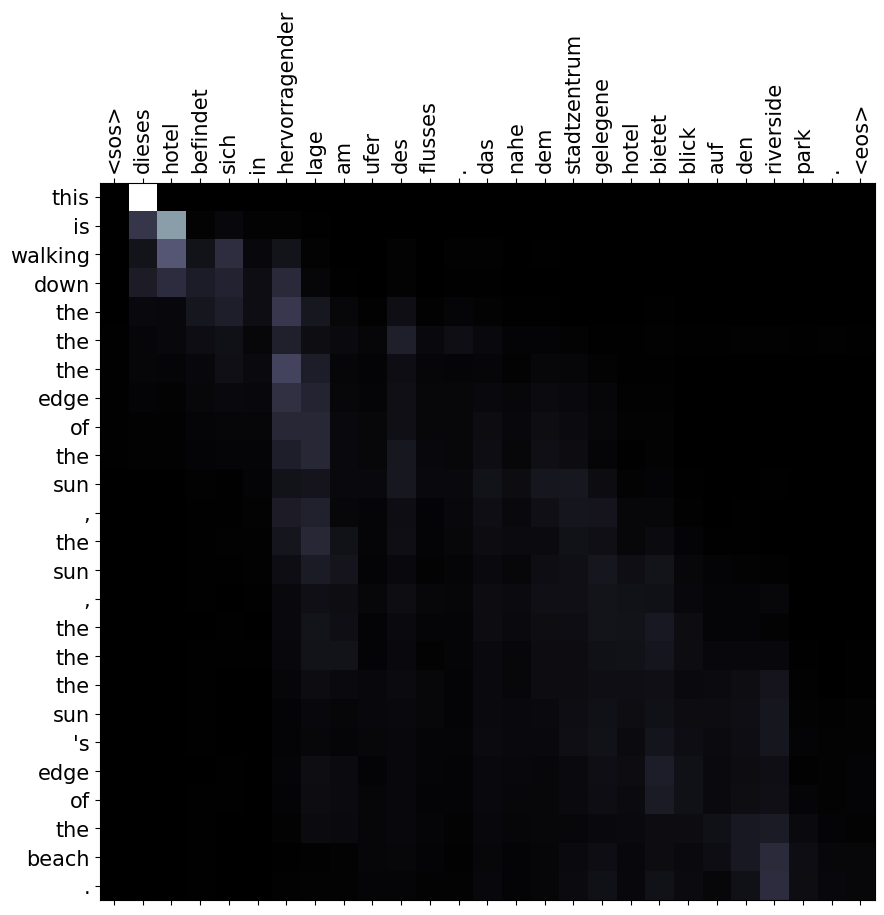

DE: <sos> wir reinigen , behandeln und sanieren wasser , boden und luft . <eos>
EN: <sos> We clean, treat and remediate water, soil and air. <eos>
TR: <sos> we are <unk> and and and and and and and and and and and and and and and and and and and and and and


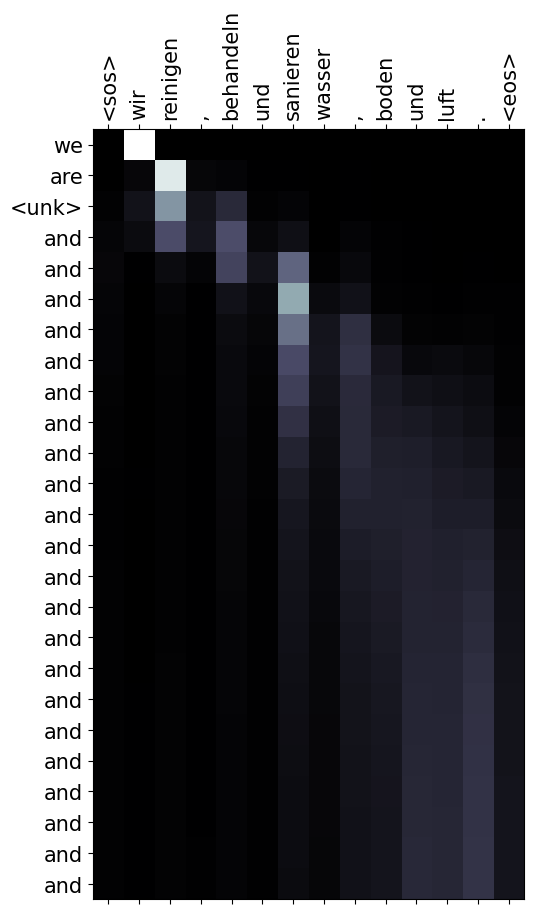

DE: <sos> alles , was sie tun müssen , ist nach dem ende der zeremonie der vergraben der opfern , auf den parkplatz für busse gehen und an bord auf einen bus der in ihre richtung fahrt . <eos>
EN: <sos> All you need to do is, go to the parking lot for buses, after the victim burial ceremony is finished, and board on a bus going in the direction of a place which you are coming from. <eos>
TR: <sos> here is what appears to be <unk> to be the the the , the the , the the , the on the the street ,


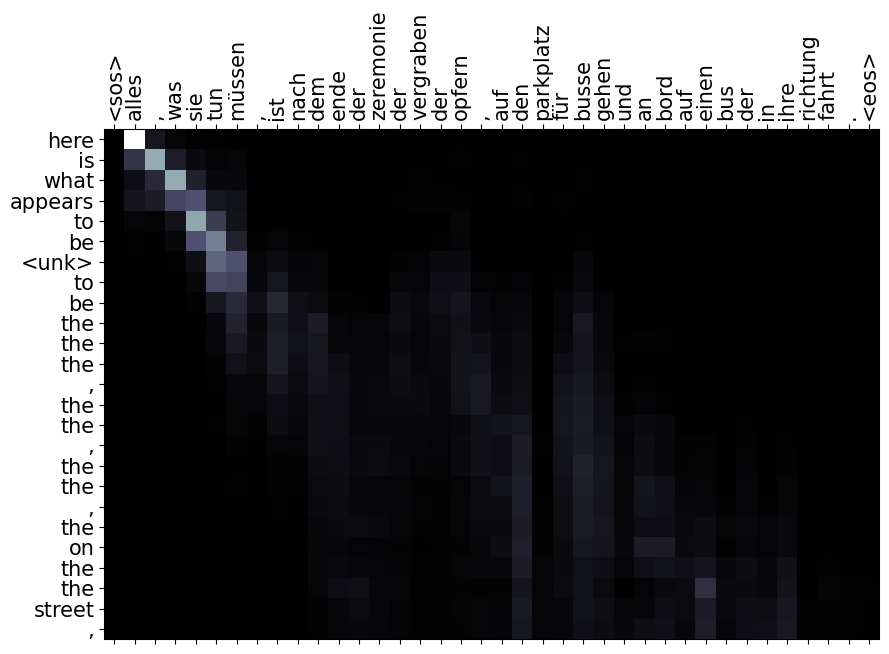

DE: <sos> unsere gäste sind touristen , polnische und ausländische unternehmen und firmen . <eos>
EN: <sos> We are always at your disposal and we help you 24 hours a day in case of any problems. <eos>
TR: <sos> <unk> are many <unk> and and and and and and and and and and and and and and and and and and and and and


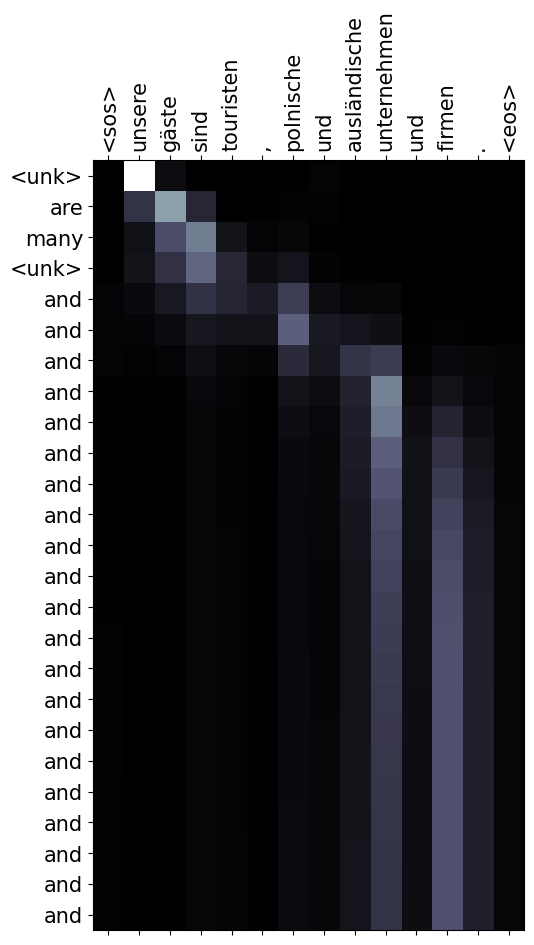

DE: <sos> es ist gut , dass die berliner mauer gefallen ist , aber es ist schlecht , dass sie uns , den menschen in osteuropa , auf den kopf gefallen ist . <eos>
EN: <sos> It is a good thing that the Berlin Wall fell down, but it is bad that it fell down on our heads, the peoples in Eastern Europe. <eos>
TR: <sos> the is <unk> to be the <unk> , , , , who is seen , who are the the , who are who is the


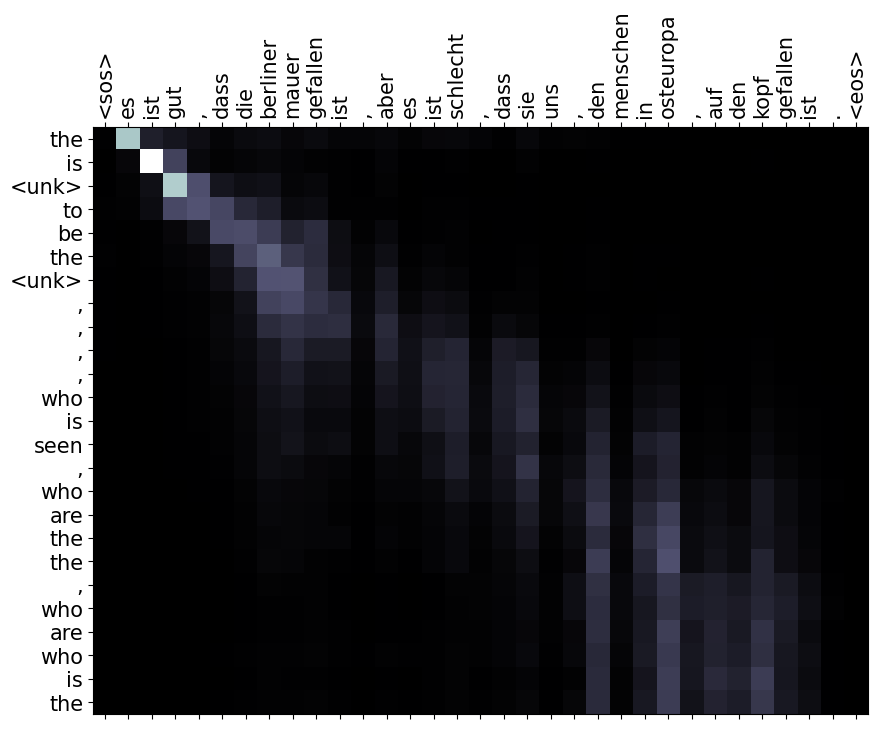

In [145]:
for _, row in large_dataframe_sorted_wc.head().iterrows():
    print('DE:', ' '.join(row['sent_tokens']))
    print('EN: <sos>', row['en'], '<eos>')
    print('TR:', ' '.join(row['translations']))
    plot_attention(row['sent_tokens'], row['translations'], row['attentions'])

In [146]:
large_dataframe_sorted_unique = large_dataframe.sort_values(by='unique_words', ascending=False)
large_dataframe_sorted_unique.head()

,translations,sent_tokens,en,word_count,unique_words,attentions
698,"[<sos>, there, are, many, many, several, kind,...","[<sos>, es, ist, möglich, mehrere, gruppen, vo...",It is possible to unite more classes into one ...,14,14,"[[[tensor(0.0066), tensor(0.6584), tensor(0.05..."
797,"[<sos>, i, am, demonstrating, his, eyes, and, ...","[<sos>, ich, kann, nur, meine, augen, schließe...",I can only shut my eyes and slowly open them a...,13,13,"[[[tensor(0.0022), tensor(0.8858), tensor(0.05..."
328,"[<sos>, six, children, are, four, adults, (, <...","[<sos>, alle, älteren, kinder, oder, erwachsen...",All older children or adults are charged GBP 1...,13,13,"[[[tensor(0.0041), tensor(0.8351), tensor(0.09..."
396,"[<sos>, the, person, is, looking, at, the, <un...","[<sos>, der, mensch, sieht, auf, die, äußere, ...","3: 2-3 . Ye must press forward, having a perfe...",15,13,"[[[tensor(0.0209), tensor(0.6925), tensor(0.00..."
173,"[<sos>, students, are, as, they, are, a, child...","[<sos>, was, machen, sie, ,, wenn, zwischendur...",What will you do if a child is fatally injured...,17,13,"[[[tensor(0.0027), tensor(0.9823), tensor(0.00..."


DE: <sos> es ist möglich mehrere gruppen von verschiedenen klassen in einer stunde zusammenzufassen , oder einer unterrichtsstunde mehrere lehrer zuzuordnen . <eos>
EN: <sos> It is possible to unite more classes into one lesson or to have more teachers for one lesson. <eos>
TR: <sos> there are many many several kind of various <unk> ) in a <unk> <unk> or <unk> , <unk> <unk> <unk> . <eos>


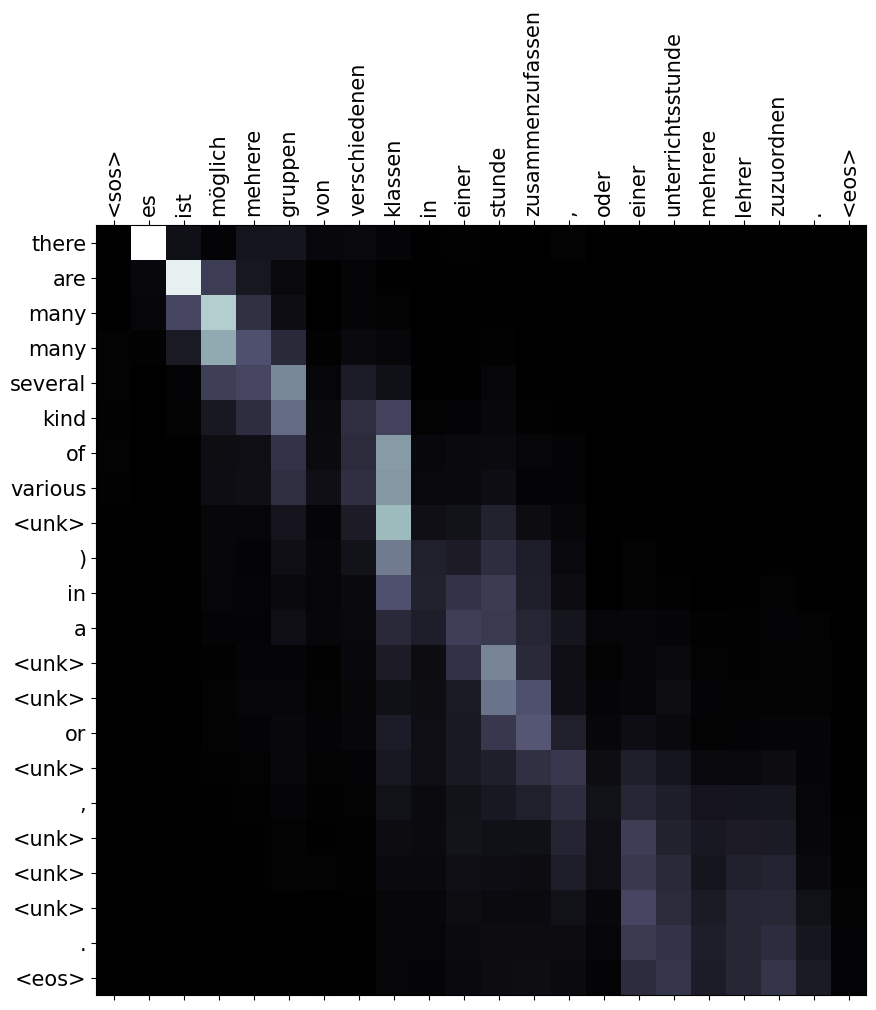

DE: <sos> ich kann nur meine augen schließen und sie langsam wieder öffnen ... <eos>
EN: <sos> I can only shut my eyes and slowly open them again... <eos>
TR: <sos> i am demonstrating his eyes and his <unk> , he is <unk> on the . <eos>


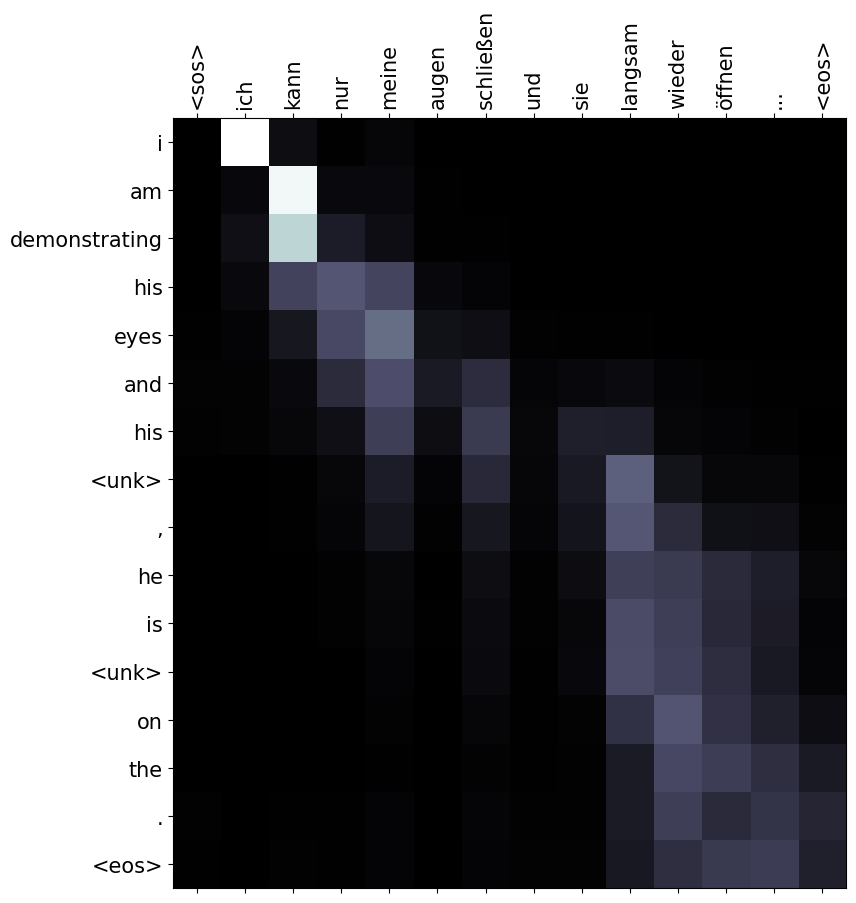

DE: <sos> alle älteren kinder oder erwachsene zahlen gbp 15,00 pro übernachtung und person in einem der vorhandenen betten . <eos>
EN: <sos> All older children or adults are charged GBP 15.00 per night and person when using existing bedding. <eos>
TR: <sos> six children are four adults ( <unk> <unk> <unk> <unk> <unk> , and <unk> in the <unk> in a <unk> . <eos>


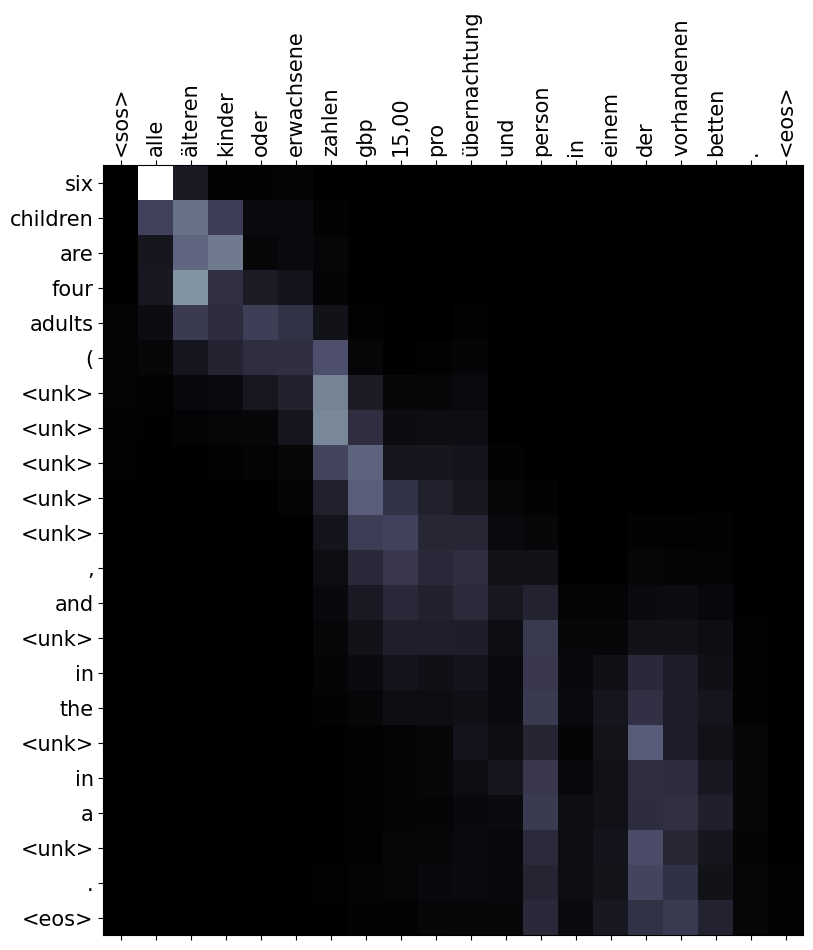

DE: <sos> der mensch sieht auf die äußere erscheinung , der herr aber sieht auf das herz 1 sam 16:7. <eos>
EN: <sos> 3: 2-3 . Ye must press forward, having a perfect brightness of hope, 2 Ne. <eos>
TR: <sos> the person is looking at the <unk> <unk> , the gentleman 's <unk> on the <unk> of a <unk> . <eos>


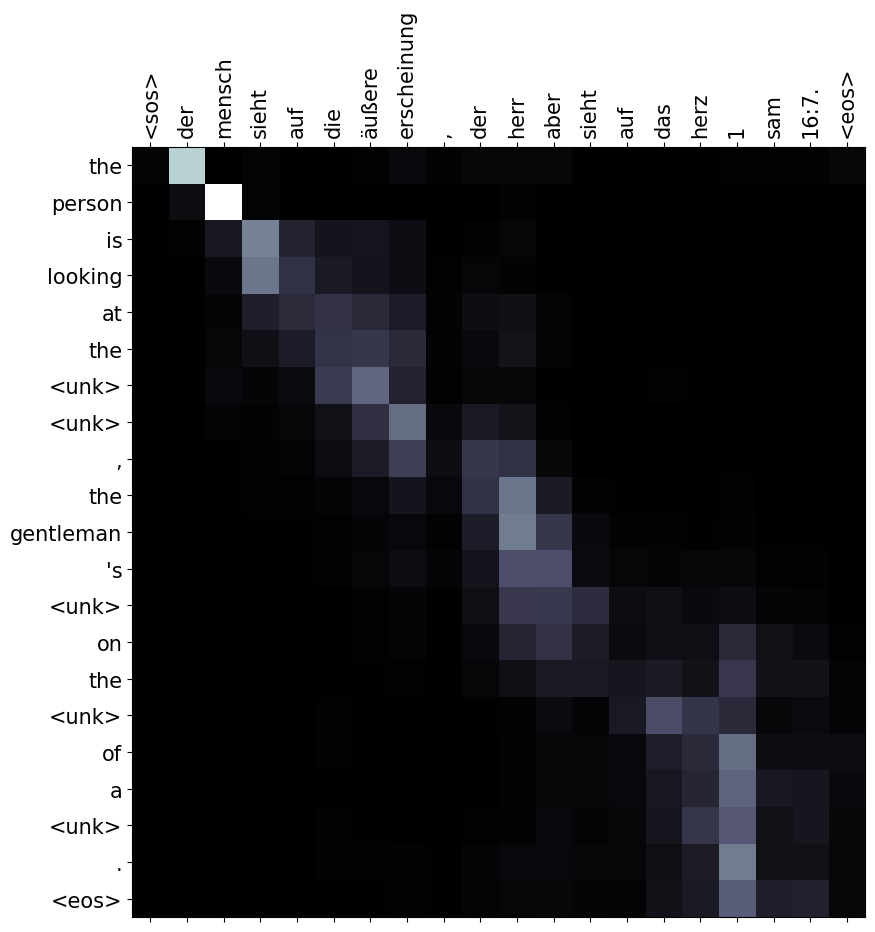

DE: <sos> was machen sie , wenn zwischendurch ein kind tödlich verunglückt , und sie , weil sie gezögert haben , sind dann mitverantwortlich ? <eos>
EN: <sos> What will you do if a child is fatally injured in the meantime and you are partly responsible because you delayed taking action? <eos>
TR: <sos> students are as they are a child , <unk> , and <unk> , they are about to be . <eos>


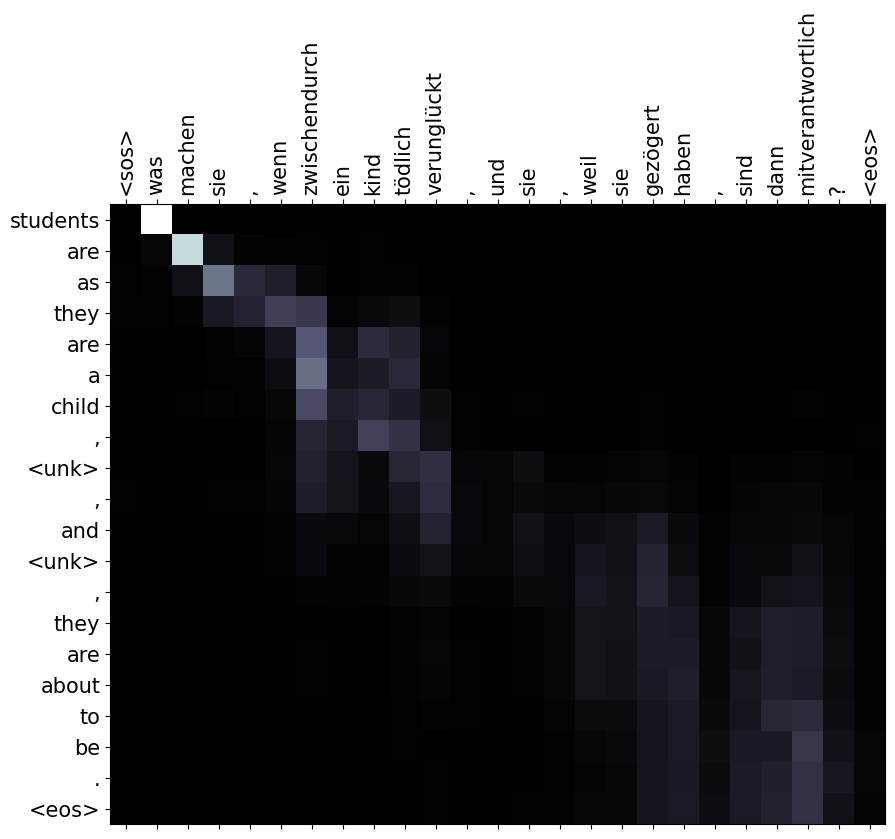

In [147]:
for _, row in large_dataframe_sorted_unique.head().iterrows():
    print('DE:', ' '.join(row['sent_tokens']))
    print('EN: <sos>', row['en'], '<eos>')
    print('TR:', ' '.join(row['translations']))
    plot_attention(row['sent_tokens'], row['translations'], row['attentions'])

## Complexity/Stress Test Dataset

In [58]:
# Load complex de-en dataset. Dataset from https://www.manythings.org/anki/
complex_dataset = pd.read_csv('deu-eng/deu.txt', names=['en', 'de', 'ack'], sep='\t', header=None).dropna()
complex_dataset['word_count'] = complex_dataset['de'].apply(lambda x: (len(x.split())) + 1)
complex_dataset['complexity'] = complex_dataset['de'].apply(lambda x: (len(x.split()) // 25) + 1)
stress_eval_dataset = datasets.Dataset(Table.from_pandas(complex_dataset[['en', 'de', 'complexity']]))
stress_eval_dataset

Dataset({
    features: ['en', 'de', 'word_count', 'complexity'],
    num_rows: 277891
})

In [59]:
# Tokenize Stress Data
fn_kwargs = {
    "en_nlp": en_nlp,
    "de_nlp": de_nlp,
    "max_length": max_length,
    "lower": lower,
    "sos_token": sos_token,
    "eos_token": eos_token,
}
stress_data = stress_eval_dataset.map(tokenize_example, fn_kwargs=fn_kwargs)

# Get Token IDS for Stress Data
fn_kwargs = {"en_vocab": en_vocab, "de_vocab": de_vocab}
stress_data = stress_data.map(numericalize_example, fn_kwargs=fn_kwargs)

Map:   0%|          | 0/277891 [00:00<?, ? examples/s]

Map:   0%|          | 0/277891 [00:00<?, ? examples/s]

In [60]:
stress_data = stress_data.with_format(
    type=data_type,
    columns=format_columns,
    output_all_columns=True,
)

In [61]:
model.load_state_dict(torch.load("tut3-model.pt"))

stress_translations = [
    translate_sentence(
        example["de"],
        model,
        en_nlp,
        de_nlp,
        en_vocab,
        de_vocab,
        lower,
        sos_token,
        eos_token,
        device,
    )
    for example in tqdm.tqdm(stress_data)
]

100%|█████████████████████████████████████████████████████████████████████████| 277891/277891 [1:05:52<00:00, 70.31it/s]


In [62]:
bleu = evaluate.load("bleu")
predictions = [" ".join(translation[0][1:-1]) for translation in stress_translations]
references = [[example["en"]] for example in stress_data]

In [63]:
tokenizer_fn = get_tokenizer_fn(en_nlp, lower)
results = bleu.compute(
    predictions=predictions, references=references, tokenizer=tokenizer_fn
)
results

{'bleu': 0.006915288204344252,
 'precisions': [0.10663003298628006,
  0.010999297594836175,
  0.0027416478671808664,
  0.0007111888984018115],
 'brevity_penalty': 1.0,
 'length_ratio': 2.15550808277566,
 'translation_length': 4634351,
 'reference_length': 2150004}

#### Analysis

In [149]:
class PGT_Stress(Potential_Good_Translations):
    def __init__(self):
        super().__init__()
        self.complexities = []

    def add_items(self, result, en, wc, unique, complexity):
        super().add_items(result, en, wc, unique)
        self.complexities.append(complexity)

    def make_dataframe(self):
        tmp_df = super().make_dataframe()
        tmp_df['complexities'] = self.complexities

        return tmp_df

In [164]:
stress_dataset_goods = PGT_Stress()
for result, example in zip(tqdm.tqdm(stress_translations), stress_data):
    translation, sentence_tokens, attention = result
    unk_count = translation.count('<unk>')
    if (unk_count / (len(translation) - 2) < 0.5 and np.abs(len(sentence_tokens) - len(translations) < 5)) or example['complexity'] > 1:
        stress_dataset_goods.add_items(result, example['en'], len(translation) - 2 - unk_count, 
                                       len(Counter(translation).keys()) - 2, example['complexity'])

100%|█████████████████████████████████████████████████████████████████████████| 277891/277891 [01:04<00:00, 4311.80it/s]


In [165]:
stress_dataframe = stress_dataset_goods.make_dataframe()
# stress_dataframe

In [166]:
stress_dataframe_sorted_wc = stress_dataframe.sort_values(by='word_count', ascending=False)
stress_dataframe_sorted_wc.head()

,translations,sent_tokens,en,word_count,unique_words,attentions,complexities
132123,"[<sos>, you, you, feels, you, got, so, got, go...","[<sos>, willst, du, sagen, ,, dass, ich, kein,...",Are you saying that I don't have a brain?,24,4,"[[[tensor(0.0039), tensor(0.8104), tensor(0.11...",1
56292,"[<sos>, they, are, side, side, side, side, sid...","[<sos>, sie, schritten, seite, an, seite, ., <...",They walked side-by-side.,24,2,"[[[tensor(0.0046), tensor(0.9545), tensor(0.02...",1
137506,"[<sos>, people, are, many, people, people, peo...","[<sos>, waffen, töten, keine, menschen, ., men...",Guns don't kill people. People kill people.,24,3,"[[[tensor(0.0039), tensor(0.8156), tensor(0.03...",1
123710,"[<sos>, i, am, new, york, new, york, new, york...","[<sos>, ich, hätte, gerne, einen, direktflug, ...",I'd like a nonstop flight to New York.,24,3,"[[[tensor(0.0008), tensor(0.9889), tensor(0.00...",1
149515,"[<sos>, i, new, york, new, york, new, york, yo...","[<sos>, ich, möchte, den, sechsuhrzug, nach, n...",I want to catch the six o'clock train to New Y...,24,2,"[[[tensor(0.0007), tensor(0.9755), tensor(0.00...",1


DE: <sos> willst du sagen , dass ich kein hirn habe ? <eos>
EN: <sos> Are you saying that I don't have a brain? <eos>
TR: <sos> you you feels you got so got got your your your your your your your your your your your your your your your your your


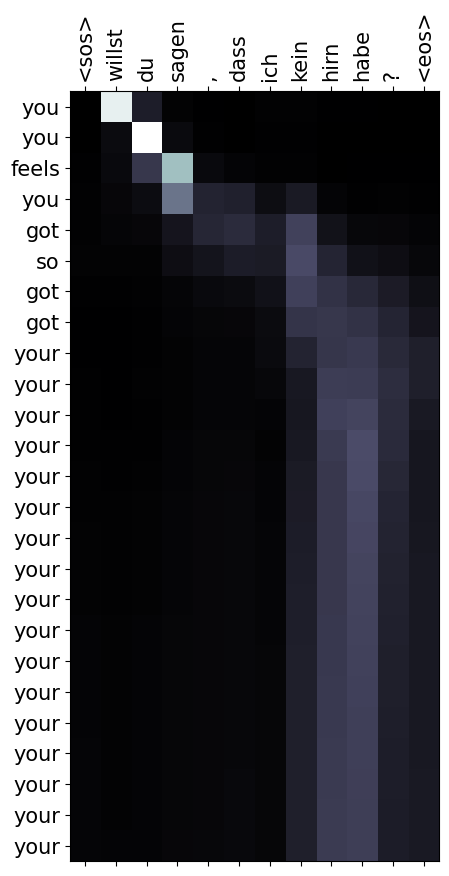

DE: <sos> sie schritten seite an seite . <eos>
EN: <sos> They walked side-by-side. <eos>
TR: <sos> they are side side side side side side side side side side side side side side side side side side side side side side side


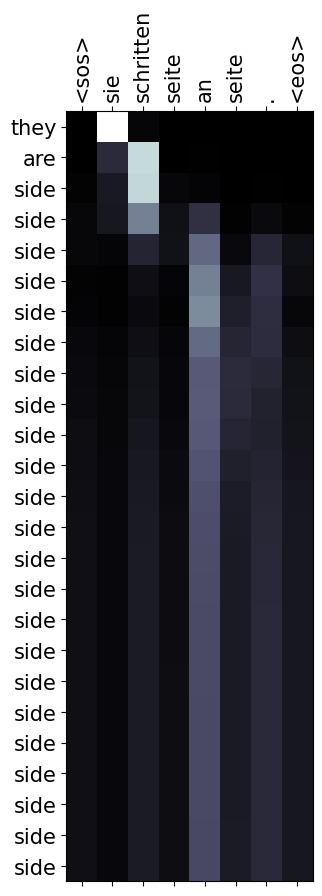

DE: <sos> waffen töten keine menschen . menschen töten menschen . <eos>
EN: <sos> Guns don't kill people. People kill people. <eos>
TR: <sos> people are many people people people people people people people people people people people people people people people people people people people people . people


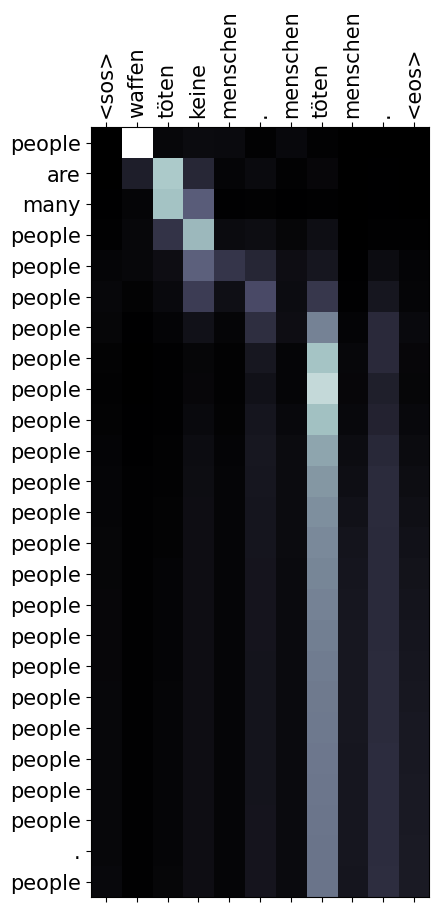

DE: <sos> ich hätte gerne einen direktflug nach new york . <eos>
EN: <sos> I'd like a nonstop flight to New York. <eos>
TR: <sos> i am new york new york new york york york york york york york york york york york york york york york york york york


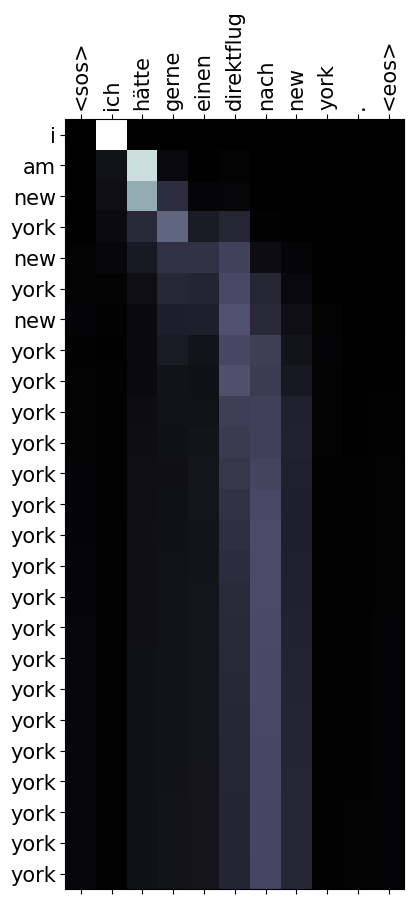

DE: <sos> ich möchte den sechsuhrzug nach new york erreichen . <eos>
EN: <sos> I want to catch the six o'clock train to New York. <eos>
TR: <sos> i new york new york new york york york york york york york york york york york york york york york york york york york


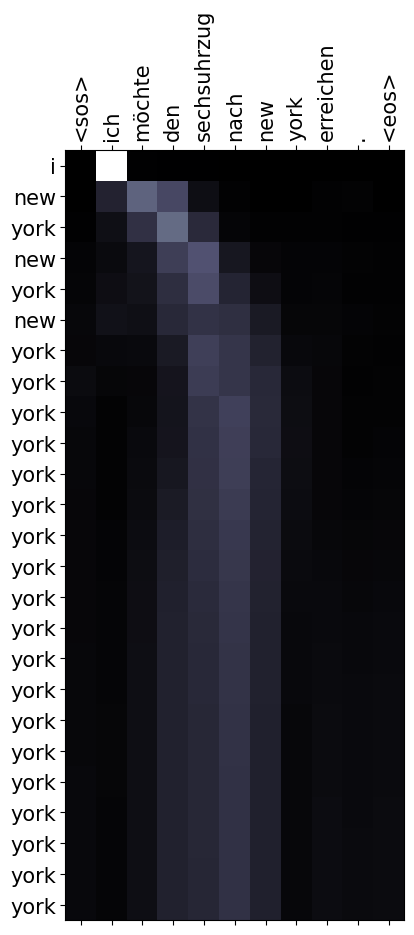

In [187]:
for _, row in stress_dataframe_sorted_wc.head().iterrows():
    print('DE:', ' '.join(row['sent_tokens']))
    print('EN: <sos>', row['en'], '<eos>')
    print('TR:', ' '.join(row['translations']))
    plot_attention(row['sent_tokens'], row['translations'], row['attentions'])

In [167]:
stress_dataframe_sorted_unique = stress_dataframe.sort_values(by='unique_words', ascending=False)
stress_dataframe_sorted_unique.head()

,translations,sent_tokens,en,word_count,unique_words,attentions,complexities
154380,"[<sos>, this, long, -, haired, <unk>, with, th...","[<sos>, wie, lange, kannst, du, mit, geschloss...",How long can you stand on one leg with your ey...,17,17,"[[[tensor(0.0025), tensor(0.9865), tensor(0.00...",1
158607,"[<sos>, i, -, aged, children, approximately, o...","[<sos>, ich, bringe, kindern, nicht, gern, das...",I don't enjoy teaching children to swim when t...,15,15,"[[[tensor(0.0021), tensor(0.9395), tensor(0.03...",1
140958,"[<sos>, <unk>, and, my, police, officers, are,...","[<sos>, tom, und, ich, saßen, im, bus, nebenei...",Tom and I sat next to each other on the bus.,14,15,"[[[tensor(0.0048), tensor(0.8445), tensor(0.04...",1
160256,"[<sos>, a, <unk>, <unk>, is, a, group, of, peo...","[<sos>, ein, komitee, ist, eine, gruppe, von, ...",A committee is a group of people who individua...,21,15,"[[[tensor(0.0064), tensor(0.1354), tensor(0.41...",2
158745,"[<sos>, here, is, my, <unk>, to, be, a, young,...","[<sos>, ich, will, mir, eins, von, diesen, hem...",I'm planning to buy one of these shirts. Maybe...,15,15,"[[[tensor(0.0033), tensor(0.9086), tensor(0.01...",1


DE: <sos> wie lange kannst du mit geschlossenen augen auf einem bein stehen ? <eos>
EN: <sos> How long can you stand on one leg with your eyes closed? <eos>
TR: <sos> this long - haired <unk> with their eyes closed on a a stand , one of them . <eos>


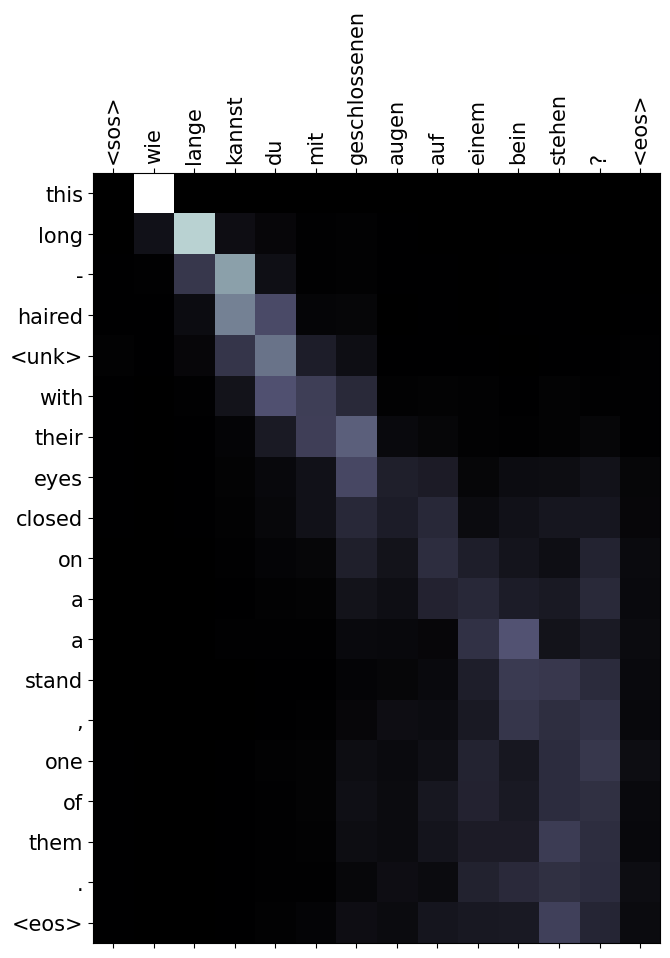

DE: <sos> ich bringe kindern nicht gern das schwimmen bei , wenn die eltern in der nähe sind . <eos>
EN: <sos> I don't enjoy teaching children to swim when their parents are around. <eos>
TR: <sos> i - aged children approximately out of the swimming pool , they are nearby . <eos>


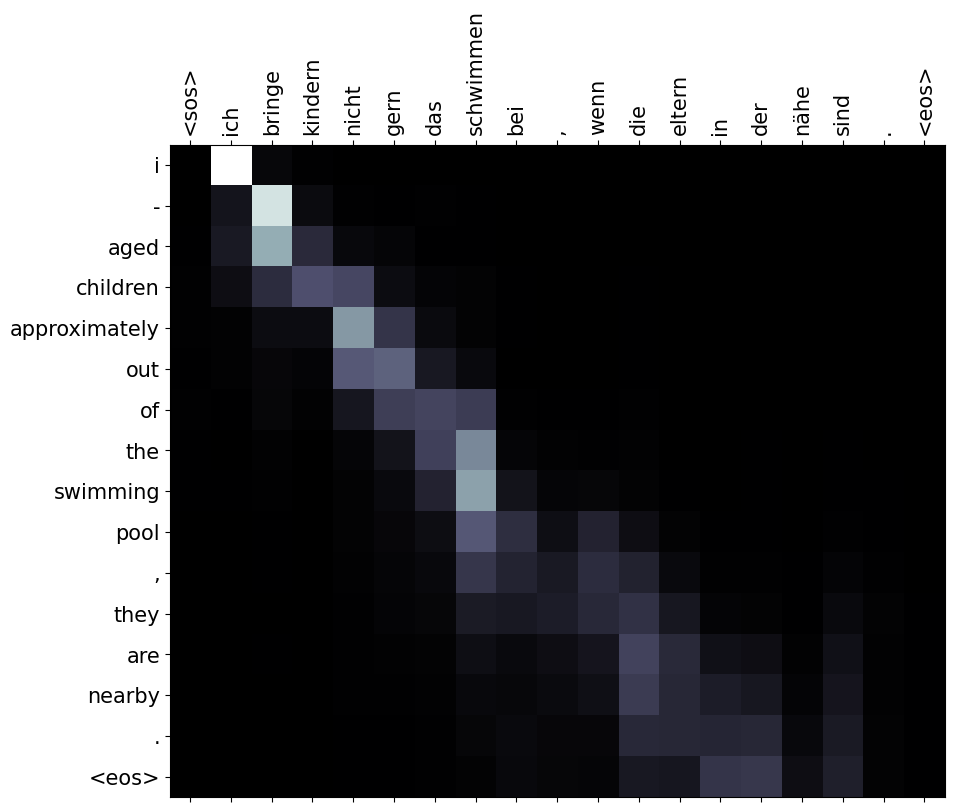

DE: <sos> tom und ich saßen im bus nebeneinander . <eos>
EN: <sos> Tom and I sat next to each other on the bus. <eos>
TR: <sos> <unk> and my police officers are standing next to each other people stand by . <eos>


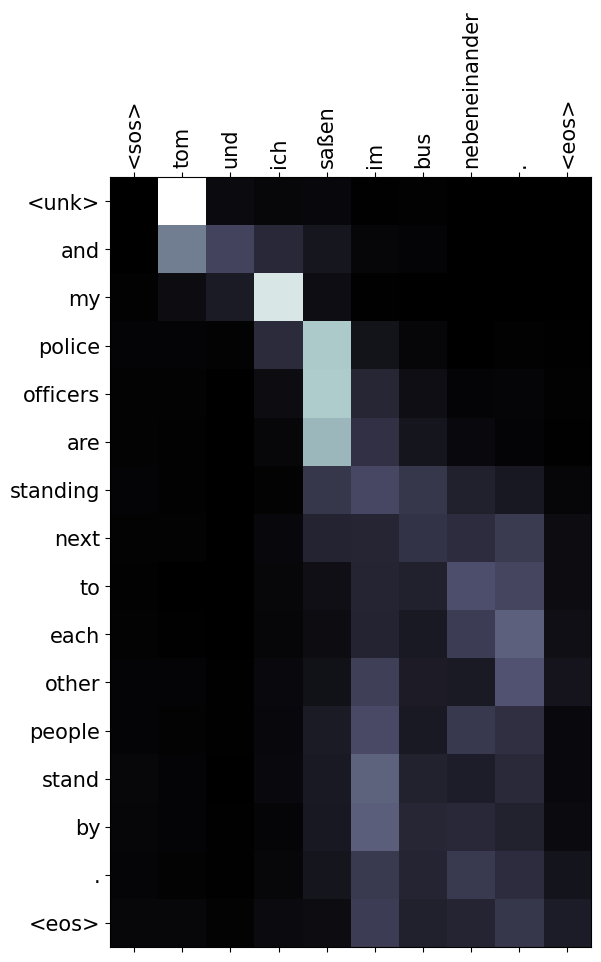

DE: <sos> ein komitee ist eine gruppe von menschen , die als einzelne nichts machen können , die aber als gruppe eine sitzung abhalten und zu der entscheidung gelangen können , dass man nichts machen kann . <eos>
EN: <sos> A committee is a group of people who individually can do nothing, but who, as a group, can meet and decide that nothing can be done. <eos>
TR: <sos> a <unk> <unk> is a group of people , as he is like the <unk> , as they are ready to the the the .


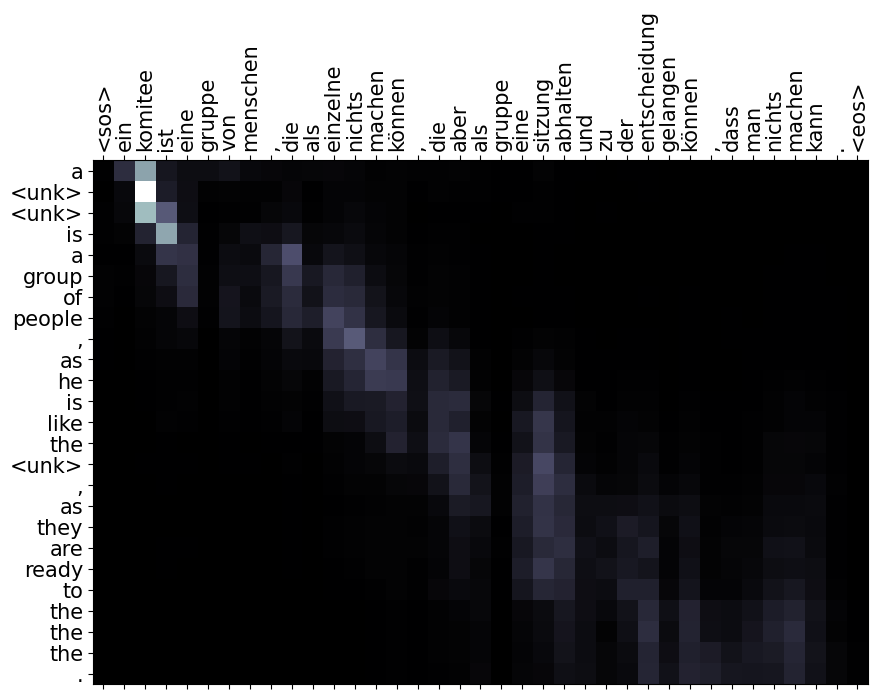

DE: <sos> ich will mir eins von diesen hemden kaufen . vielleicht solltest du dir auch eins kaufen . <eos>
EN: <sos> I'm planning to buy one of these shirts. Maybe you should buy one, too. <eos>
TR: <sos> here is my <unk> to be a young boy , <unk> by the street , and . <eos>


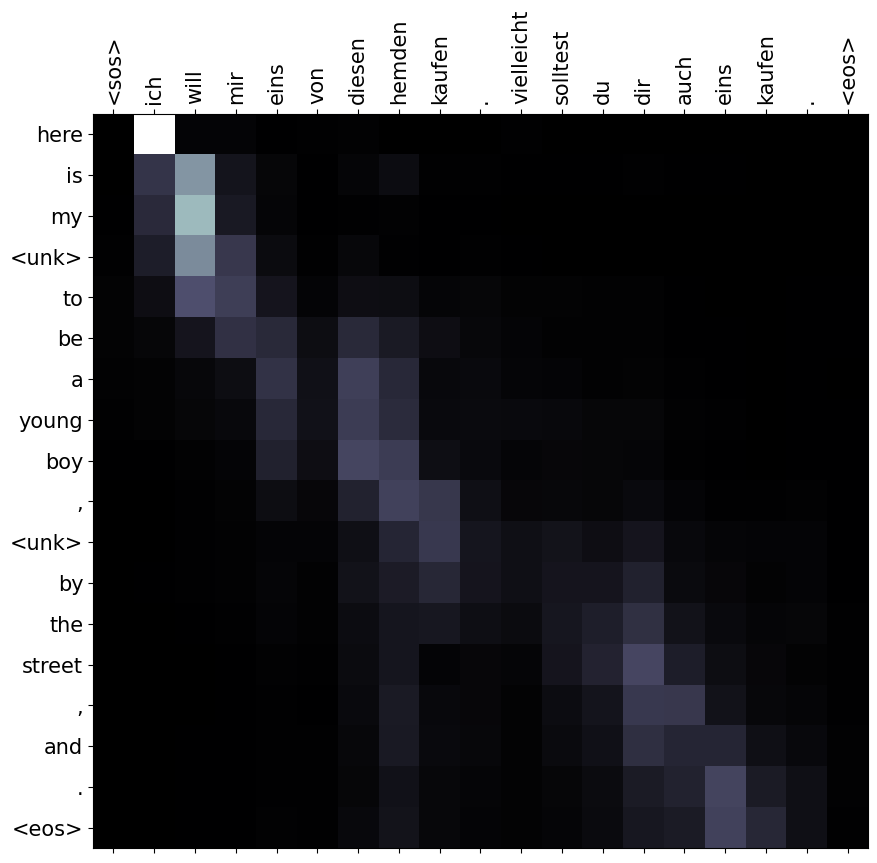

In [188]:
for _, row in stress_dataframe_sorted_unique.head().iterrows():
    print('DE:', ' '.join(row['sent_tokens']))
    print('EN: <sos>', row['en'], '<eos>')
    print('TR:', ' '.join(row['translations']))
    plot_attention(row['sent_tokens'], row['translations'], row['attentions'])

In [189]:
stress_dataframe_sorted_unique_complexities = stress_dataframe.groupby(by='complexities')
# [stress_dataframe_sorted_unique_complexities.get_group(i) for i in np.arange(1, 5)]
top_rated_of_complexities = [stress_dataframe_sorted_unique_complexities.get_group(i).sort_values(by=['word_count', 'unique_words'], 
                                                                                                  ascending=[False, False]).head(1) for i in np.arange(1, 5)]

Complexity: 1
DE: <sos> hat jeder in schweden blonde haare und blaue augen ? <eos>
EN: <sos> Does everyone in Sweden have blonde hair and blue eyes? <eos>
TR: <sos> there are in in a colors and blond - aged blue and blue and blue and blue and blue and blue and blue . <eos>


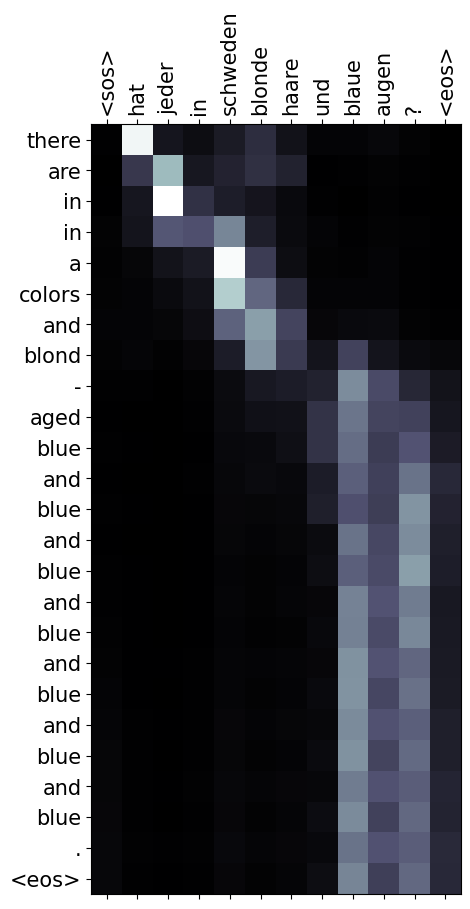

Complexity: 2
DE: <sos> es ist schwer eine frau zu sein . man muss wie ein mann denken , sich wie eine dame benehmen , wie ein mädchen aussehen und wie ein pferd arbeiten . <eos>
EN: <sos> It's hard to be a woman. One must think like a man, act like a lady, look like a girl, and work like a horse. <eos>
TR: <sos> here is a woman woman to be a man , as a woman , as a girl , and a man and a a .


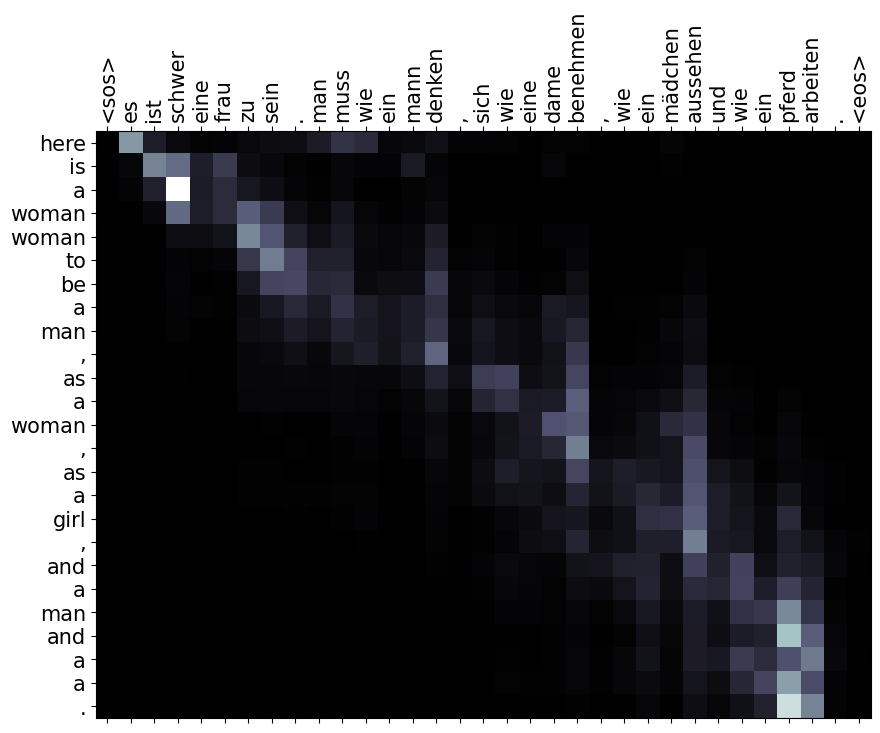

Complexity: 3
DE: <sos> wenn einem von jemandem , der nicht weiß , woher man kommt , gesagt wird , man klinge wie ein muttersprachler , dann heißt das , dass dem an der art , wie man redet , irgendwas aufgefallen sein muss , woran er erkannt hat , dass man eben keiner ist . anders ausgedrückt klingt man eher nicht wie ein muttersprachler . <eos>
EN: <sos> If someone who doesn't know your background says that you sound like a native speaker, it means they probably noticed something about your speaking that made them realize you weren't a native speaker. In other words, you don't really sound like a native speaker. <eos>
TR: <sos> a a game of what appears to be <unk> to so my <unk> so so my <unk> to see the <unk> . <eos>


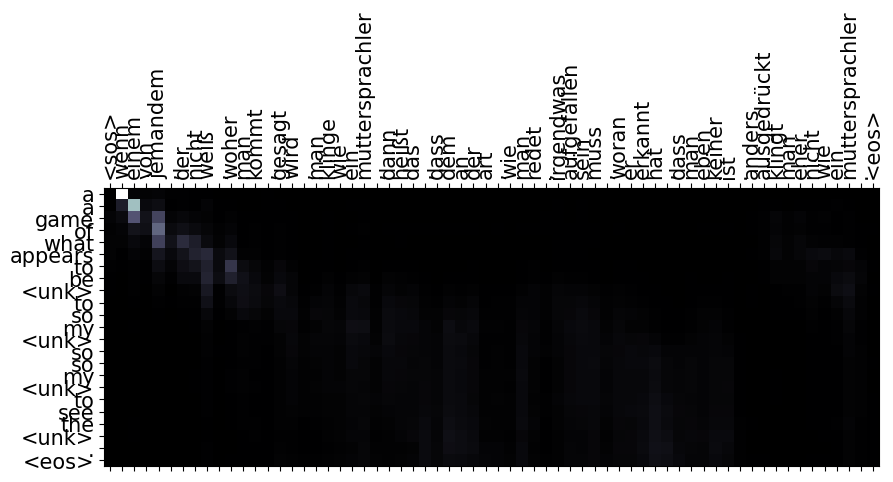

Complexity: 4
DE: <sos> ohne zweifel findet sich auf dieser welt zu jedem mann genau die richtige ehefrau und umgekehrt ; wenn man jedoch in betracht zieht , dass ein mensch nur gelegenheit hat , mit ein paar hundert anderen bekannt zu sein , von denen ihm nur ein dutzend oder weniger nahesteht , darunter höchstens ein oder zwei freunde , dann erahnt man eingedenk der millionen einwohner dieser welt   leicht , dass seit erschaffung ebenderselben wohl noch nie der richtige mann der richtigen frau begegnet ist . <eos>
EN: <sos> Doubtless there exists in this world precisely the right woman for any given man to marry and vice versa; but when you consider that a human being has the opportunity of being acquainted with only a few hundred people, and out of the few hundred that there are but a dozen or less whom he knows intimately, and out of the dozen, one or two friends at most, it will easily be seen, when we remember the number of millions who inhabit this world, that probably, since th

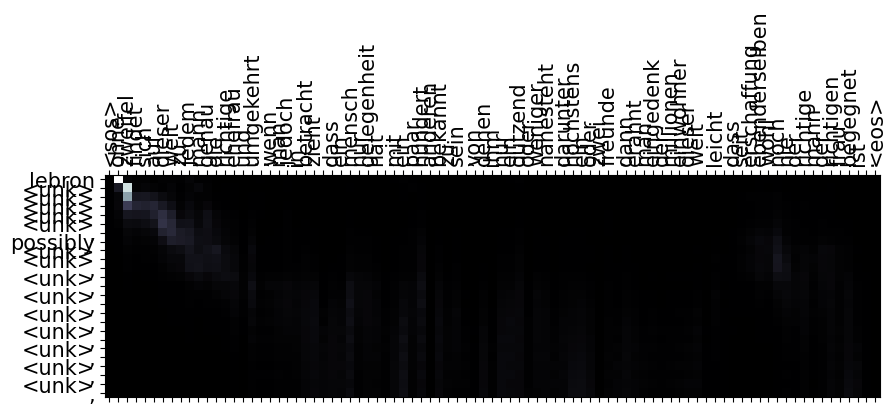

In [204]:
for top_complex in top_rated_of_complexities:
    top_row = top_complex.iloc[0]
    print('Complexity:', top_row['complexities'])
    print('DE:', ' '.join(top_row['sent_tokens']))
    print('EN: <sos>', top_row['en'], '<eos>')
    print('TR:', ' '.join(top_row['translations']))
    plot_attention(top_row['sent_tokens'], top_row['translations'], top_row['attentions'])

#### Custom Sentences

In [66]:
# sentences = ['Ich möchte das kaufen', 'Alles ist seinen Preis wert', 'Der Film war der Hammer', 'ich mochte ein bier', 'Ich möchte das kaufen']
sentences = ['ich möchte das kaufen', 'alles ist seinen Preis wert', 'wie viel kostet das', 'ich mochte ein bier ']

In [67]:
for sentence in sentences:
    translation, sentence_tokens, attention = translate_sentence(
        sentence,
        model,
        en_nlp,
        de_nlp,
        en_vocab,
        de_vocab,
        lower,
        sos_token,
        eos_token,
        device,
    )
    print(translation)

['<sos>', 'we', '<unk>', 'the', 'the', 'market', 'the', 'market', '.', '<eos>']
['<sos>', 'this', 'is', 'his', '<unk>', '<unk>', '<unk>', '<unk>', '<unk>', '.', '<eos>']
['<sos>', 'these', 'many', 'of', 'people', 'are', 'the', 'a', '.', '<eos>']
['<sos>', 'we', '<unk>', 'a', 'couple', 'are', 'a', 'beer', '.', '<eos>']
